##### Copyright 2023 The MediaPipe Authors. All Rights Reserved.

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Face Detection with MediaPipe Tasks

This notebook shows you how to use the MediaPipe Tasks Python API to detect faces in images.

## Preparation

Let's start with installing MediaPipe.

In [2]:
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.35

Found existing installation: mediapipe 0.10.35
Uninstalling mediapipe-0.10.35:
  Successfully uninstalled mediapipe-0.10.35
  Using cached mediapipe-0.10.35-py3-none-manylinux_2_28_x86_64.whl.metadata (9.8 kB)
Using cached mediapipe-0.10.35-py3-none-manylinux_2_28_x86_64.whl (12.4 MB)


Then download an off-the-shelf model. Check out the [MediaPipe documentation](https://developers.google.com/mediapipe/solutions/vision/face_detector#models) for more face detection models that you can use.

In [3]:
!wget -q -O detector.tflite -q https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite

## Visualization utilities

To better demonstrate the Face Detector API, we have created a set of visualization tools that will be used in this colab. These will draw a bounding box around detected faces, as well as markers over certain detected points on the faces.

In [4]:
from typing import Tuple, Union
import math
import cv2
import numpy as np

MARGIN = 10  # pixels
ROW_SIZE = 10  # pixels
FONT_SIZE = 1
FONT_THICKNESS = 1
TEXT_COLOR = (255, 0, 0)  # red


def _normalized_to_pixel_coordinates(
    normalized_x: float, normalized_y: float, image_width: int,
    image_height: int) -> Union[None, Tuple[int, int]]:
  """Converts normalized value pair to pixel coordinates."""

  # Checks if the float value is between 0 and 1.
  def is_valid_normalized_value(value: float) -> bool:
    return (value > 0 or math.isclose(0, value)) and (value < 1 or
                                                      math.isclose(1, value))

  if not (is_valid_normalized_value(normalized_x) and
          is_valid_normalized_value(normalized_y)):
    # TODO: Draw coordinates even if it's outside of the image bounds.
    return None
  x_px = min(math.floor(normalized_x * image_width), image_width - 1)
  y_px = min(math.floor(normalized_y * image_height), image_height - 1)
  return x_px, y_px


def visualize(
    image,
    detection_result
) -> np.ndarray:
  """Draws bounding boxes and keypoints on the input image and return it.
  Args:
    image: The input RGB image.
    detection_result: The list of all "Detection" entities to be visualize.
  Returns:
    Image with bounding boxes.
  """
  annotated_image = image.copy()
  height, width, _ = image.shape

  for detection in detection_result.detections:
    # Draw bounding_box
    bbox = detection.bounding_box
    start_point = bbox.origin_x, bbox.origin_y
    end_point = bbox.origin_x + bbox.width, bbox.origin_y + bbox.height
    cv2.rectangle(annotated_image, start_point, end_point, TEXT_COLOR, 3)

    # Draw keypoints
    for keypoint in detection.keypoints:
      keypoint_px = _normalized_to_pixel_coordinates(keypoint.x, keypoint.y,
                                                     width, height)
      color, thickness, radius = (0, 255, 0), 2, 2
      cv2.circle(annotated_image, keypoint_px, thickness, color, radius)

    # Draw label and score
    category = detection.categories[0]
    category_name = category.category_name
    category_name = '' if category_name is None else category_name
    probability = round(category.score, 2)
    result_text = category_name + ' (' + str(probability) + ')'
    text_location = (MARGIN + bbox.origin_x,
                     MARGIN + ROW_SIZE + bbox.origin_y)
    cv2.putText(annotated_image, result_text, text_location, cv2.FONT_HERSHEY_PLAIN,
                FONT_SIZE, TEXT_COLOR, FONT_THICKNESS)

  return annotated_image

## Download test image

To demonstrate Face Detection, you can download a sample image using the following code. Credits: https://pixabay.com/photos/brother-sister-girl-family-boy-977170/

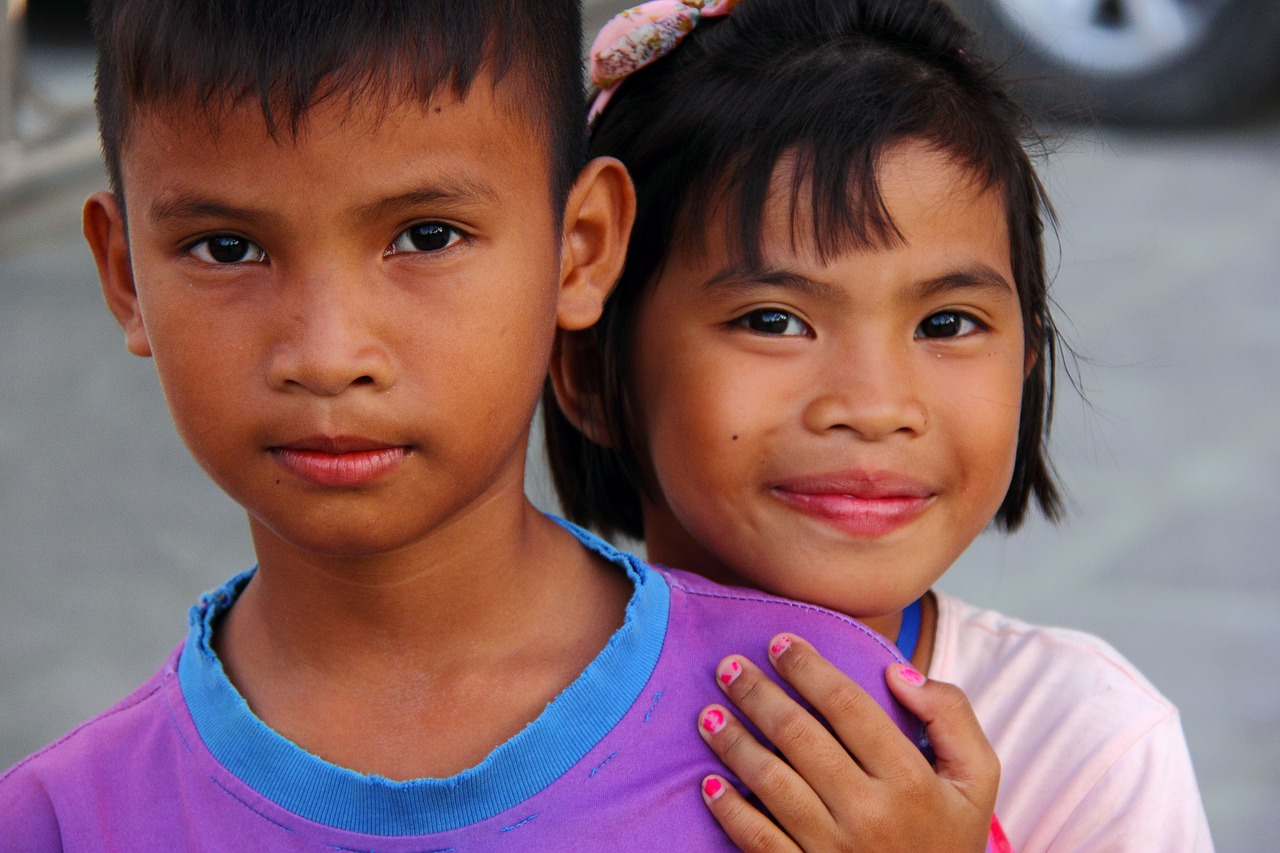

In [5]:
!curl https://i.imgur.com/Vu2Nqwb.jpeg -s -o image.jpg

IMAGE_FILE = 'image.jpg'

import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread(IMAGE_FILE)
cv2_imshow(img)

Optionally, you can upload your own image from your computer. To do this, uncomment the following code cell.

In [6]:
from google.colab import files
uploaded = files.upload()

for filename in uploaded:
  content = uploaded[filename]
  with open(filename, 'wb') as f:
    f.write(content)

if len(uploaded.keys()):
  IMAGE_FILE = next(iter(uploaded))
  print('Uploaded file:', IMAGE_FILE)

Saving tilt-to-right.jpg to tilt-to-right (2).jpg
Uploaded file: tilt-to-right (2).jpg


## Running inference and visualizing the results

The final step is to run face detection on your selected image. This involves creating your FaceDetector object, loading your image, running detection, and finally, the optional step of displaying the image with visualizations.

You can check out the [MediaPipe documentation](https://developers.google.com/mediapipe/solutions/vision/face_detector/python) to learn more about configuration options that this solution supports.

In [7]:
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2
import math

# STEP 2: Create an FaceDetector object.
base_options = python.BaseOptions(model_asset_path='detector.tflite')
options = vision.FaceDetectorOptions(base_options=base_options)
detector = vision.FaceDetector.create_from_options(options)

# Initialize MediaPipe Face Mesh for more detailed landmark detection
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(min_detection_confidence=0.5,
                                  min_tracking_confidence=0.5)

def rotation_matrix_to_angles(rotation_matrix):
    """
    Calculate Euler angles (pitch, yaw, roll) from a 3x3 rotation matrix.
    The angles are returned in degrees.
    """
    # Pitch (rotation around X-axis)
    pitch = math.atan2(rotation_matrix[2, 1], rotation_matrix[2, 2])
    # Yaw (rotation around Y-axis)
    yaw = math.atan2(-rotation_matrix[2, 0], math.sqrt(rotation_matrix[0, 0] ** 2 +
                                                     rotation_matrix[1, 0] ** 2))
    # Roll (rotation around Z-axis)
    roll = math.atan2(rotation_matrix[1, 0], rotation_matrix[0, 0])
    return np.array([pitch, yaw, roll]) * 180. / math.pi

# STEP 3: Load the input image.
image = mp.Image.create_from_file(IMAGE_FILE)

# STEP 4: Detect faces in the input image.
detection_result = detector.detect(image)

# STEP 5: Process the detection result. In this case, visualize it.
image_copy = np.copy(image.numpy_view())
annotated_image = visualize(image_copy, detection_result)
rgb_annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
cv2_imshow(rgb_annotated_image)


AttributeError: module 'mediapipe' has no attribute 'solutions'

In [ ]:
import math

import cv2
import mediapipe as mp
import numpy as np
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2

In [ ]:
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(min_detection_confidence=0.5,
                                  min_tracking_confidence=0.5)

def rotation_matrix_to_angles(rotation_matrix):
    """
    Calculate Euler angles from rotation matrix.
    :param rotation_matrix: A 3*3 matrix with the following structure
    [Cosz*Cosy  Cosz*Siny*Sinx - Sinz*Cosx  Cosz*Siny*Cosx + Sinz*Sinx]
    [Sinz*Cosy  Sinz*Siny*Sinx + Sinz*Cosx  Sinz*Siny*Cosx - Cosz*Sinx]
    [  -Siny             CosySinx                   Cosy*Cosx         ]
    :return: Angles in degrees for each axis
    """
    x = math.atan2(rotation_matrix[2, 1], rotation_matrix[2, 2])
    y = math.atan2(-rotation_matrix[2, 0], math.sqrt(rotation_matrix[0, 0] ** 2 +
                                                     rotation_matrix[1, 0] ** 2))
    z = math.atan2(rotation_matrix[1, 0], rotation_matrix[0, 0])
    return np.array([x, y, z]) * 180. / math.pi

In [ ]:
while cap.isOpened():
    success, image = cap.read()

    # Convert the color space from BGR to RGB and get Mediapipe results
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(image)

    # Convert the color space from RGB to BGR to display well with Opencv
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    face_coordination_in_real_world = np.array([
        [285, 528, 200],
        [285, 371, 152],
        [197, 574, 128],
        [173, 425, 108],
        [360, 574, 128],
        [391, 425, 108]
    ], dtype=np.float64)

    h, w, _ = image.shape
    face_coordination_in_image = []

    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            for idx, lm in enumerate(face_landmarks.landmark):
                if idx in [1, 9, 57, 130, 287, 359]:
                    x, y = int(lm.x * w), int(lm.y * h)
                    face_coordination_in_image.append([x, y])

            face_coordination_in_image = np.array(face_coordination_in_image,
                                                  dtype=np.float64)

            # The camera matrix
            focal_length = 1 * w
            cam_matrix = np.array([[focal_length, 0, w / 2],
                                   [0, focal_length, h / 2],
                                   [0, 0, 1]])

            # The Distance Matrix
            dist_matrix = np.zeros((4, 1), dtype=np.float64)

            # Use solvePnP function to get rotation vector
            success, rotation_vec, transition_vec = cv2.solvePnP(
                face_coordination_in_real_world, face_coordination_in_image,
                cam_matrix, dist_matrix)

            # Use Rodrigues function to convert rotation vector to matrix
            rotation_matrix, jacobian = cv2.Rodrigues(rotation_vec)

            result = rotation_matrix_to_angles(rotation_matrix)
            for i, info in enumerate(zip(('pitch', 'yaw', 'roll'), result)):
                k, v = info
                text = f'{k}: {int(v)}'
                cv2.putText(image, text, (20, i*30 + 20),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200, 0, 200), 2)


    cv2.imshow('Head Pose Angles', image)

    if cv2.waitKey(5) & 0xFF == 27:
        break

cap.release()

In [ ]:
def analyze_face_image(image_path: str) -> str:
  """
  Analyzes an image for face characteristics based on predefined criteria,
  including a more precise head pose estimation.

  Args:
    image_path: The path to the input image file.

  Returns:
    A string describing the classification result (e.g., "正常", "人脸距离过近", etc.).
  """
  global detector, face_mesh # Access the detector and face_mesh initialized in prior cells

  try:
    # Load the input image using MediaPipe for FaceDetector
    mp_image = mp.Image.create_from_file(image_path)
    image_width, image_height = mp_image.width, mp_image.height

    # Also load using OpenCV for FaceMesh and pose estimation
    cv_image_bgr = cv2.imread(image_path)
    if cv_image_bgr is None:
        return f"处理图片时发生错误: 无法加载图片 {image_path}"
    cv_image_rgb_for_mesh = cv2.cvtColor(cv_image_bgr, cv2.COLOR_BGR2RGB)

    # Detect faces with MediaPipe Face Detector for bounding box, etc.
    detection_result = detector.detect(mp_image)

    # 8. 未检测到人脸
    if not detection_result.detections:
      return "未检测到人脸"

    # 9. 出现多个目标人脸
    if len(detection_result.detections) > 1:
      return "出现多个目标人脸"

    # Process a single detected face from Face Detector
    detection = detection_result.detections[0]
    bbox = detection.bounding_box

    # Image center
    image_center_x = image_width / 2
    image_center_y = image_height / 2

    # Face center (pixel coordinates)
    face_center_x = bbox.origin_x + bbox.width / 2
    face_center_y = bbox.origin_y + bbox.height / 2

    # Define thresholds (these might need tuning based on specific requirements)
    # Relative area thresholds for distance
    TOO_CLOSE_THRESHOLD_AREA = 0.35 # Face area > 35% of image area
    TOO_FAR_THRESHOLD_AREA = 0.05   # Face area < 5% of image area

    # Position deviation thresholds (relative to image dimensions)
    POSITION_THRESHOLD_X = image_width * 0.20
    POSITION_THRESHOLD_Y = image_height * 0.20

    # New orientation thresholds in degrees for pitch and yaw
    YAW_THRESHOLD_DEG = 20    # Yaw deviation threshold in degrees
    PITCH_THRESHOLD_DEG = 20  # Pitch deviation threshold in degrees

    # 2. 人脸距离过近, 3. 人脸距离过远
    face_area = bbox.width * bbox.height
    image_area = image_width * image_height
    relative_face_area = face_area / image_area

    if relative_face_area > TOO_CLOSE_THRESHOLD_AREA:
      return "人脸距离过近"
    if relative_face_area < TOO_FAR_THRESHOLD_AREA:
      return "人脸距离过远"

    # 4-7. 人脸位置偏左/右/上/下
    if face_center_x < image_center_x - POSITION_THRESHOLD_X:
      return "人脸位置偏左"
    if face_center_x > image_center_x + POSITION_THRESHOLD_X:
      return "人脸位置偏右"
    if face_center_y < image_center_y - POSITION_THRESHOLD_Y:
      return "人脸位置偏上"
    if face_center_y > image_center_y + POSITION_THRESHOLD_Y:
      return "人脸位置偏下"

    # 10. 人脸朝向偏离过多（没有面向镜头） - Using Face Mesh for precise pose estimation
    mesh_results = face_mesh.process(cv_image_rgb_for_mesh)

    if not mesh_results.multi_face_landmarks:
        # If Face Detector found a face but Face Mesh didn't find landmarks, this indicates an issue
        return "无法进行人脸朝向估算（未检测到足够关键点）"

    face_coordination_in_real_world = np.array([
        [285, 528, 200],
        [285, 371, 152],
        [197, 574, 128],
        [173, 425, 108],
        [360, 574, 128],
        [391, 425, 108]
    ], dtype=np.float64)

    face_coordination_in_image = []
    # Use the first face found by Face Mesh (consistent with single face expectation)
    for idx, lm in enumerate(mesh_results.multi_face_landmarks[0].landmark):
        # Only select the keypoints that correspond to the real-world model points
        if idx in [1, 9, 57, 130, 287, 359]:
            x, y = int(lm.x * image_width), int(lm.y * image_height)
            face_coordination_in_image.append([x, y])

    if len(face_coordination_in_image) != 6:
        return "无法进行人脸朝向估算（关键点数量不足）"
    face_coordination_in_image = np.array(face_coordination_in_image, dtype=np.float64)

    # Camera matrix (assuming simple pinhole model, focal length as image width)
    focal_length = 1 * image_width
    cam_matrix = np.array([[focal_length, 0, image_width / 2],
                           [0, focal_length, image_height / 2],
                           [0, 0, 1]], dtype=np.float64)

    # Distance matrix (assuming no lens distortion)
    dist_matrix = np.zeros((4, 1), dtype=np.float64)

    # Use solvePnP to get rotation and translation vectors
    success, rotation_vec, _ = cv2.solvePnP(
        face_coordination_in_real_world, face_coordination_in_image,
        cam_matrix, dist_matrix, flags=cv2.SOLVEPNP_ITERATIVE) # Using iterative flag for robustness

    if not success:
        return "人脸朝向估算失败"

    # Convert rotation vector to rotation matrix
    rotation_matrix, _ = cv2.Rodrigues(rotation_vec)

    # Get Euler angles (pitch, yaw, roll)
    pitch, yaw, roll = rotation_matrix_to_angles(rotation_matrix)

    # Check for excessive deviation in yaw and pitch
    if abs(yaw) > YAW_THRESHOLD_DEG or abs(pitch) > PITCH_THRESHOLD_DEG:
        return "人脸朝向偏离过多（没有面向镜头）"

    # 1. 正常（包含一个居中、大小、朝向正常的儿童人脸，排除所有非儿童人脸）
    # IMPORTANT LIMITATION: MediaPipe Face Detector does NOT inherently provide age estimation
    # to distinguish "child faces" from "non-child faces".
    # Therefore, this function cannot strictly enforce "排除所有非儿童人脸".
    # It assumes that any face that passes all other geometric and orientation checks
    # is considered "正常" for the purpose of this exercise.
    return "正常"

  except Exception as e:
    return f"处理图片时发生错误: {e}"

# Example usage with the current IMAGE_FILE
print(f"分析图片 '{IMAGE_FILE}' 的结果: {analyze_face_image(IMAGE_FILE)}")
